# Hierarchical Statistics for Platform Paper
# Using Mixed Linear Models with Pairwise Comparisons

**Purpose:** Replace the current ANOVA + Tukey HSD approach with a mixed linear model 
that accounts for the nested structure of the data (cells within mice). This addresses 
reviewer concerns about pseudoreplication.

**Background:**  
Our data has multiple cells per mouse, and the same mouse contributes observations 
across experience levels. Standard ANOVA treats each cell as an independent observation, 
which inflates sample size and can produce overly liberal p-values. A mixed linear model 
(MLM) with mouse as a random effect properly accounts for this non-independence.

**Approach:**  
We use `statsmodels.formula.api.mixedlm` with a random intercept for `mouse_id`. 
Based on prior analysis (see `251102_test_hierarchical_stats.ipynb`):
- A random intercept model significantly improves over Ordinary Least Squares (OLS) (likelhood ratio test (LRT) p < 1e-22)
- Adding random slopes causes convergence failures and does not improve fit
- Mouse-level variance is very small relative to cell-level variance
- Therefore, a random intercept model is sufficient

We also compute the ICC (intraclass correlation coefficient) for each metric to 
quantify what proportion of total variance is attributable to mouse identity. This 
provides per-metric justification for the random intercept model and is reported 
alongside the pairwise comparison results.

For pairwise comparisons, the MLM summary provides p-values for each non-reference 
level vs. the reference (e.g., Novel vs Familiar, Novel+ vs Familiar). To get the 
third comparison (Novel vs Novel+), we compute a Wald test on the difference between 
the two coefficients. All three comparisons come from the same single model fit — the 
Wald contrast is not a separate test, just a different question asked of the same 
fitted model and its covariance matrix.


In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

In [40]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading
import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.dimensionality_reduction.clustering.processing as processing

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

## Load data
Using the same loading approach as in `251102_test_hierarchical_stats.ipynb`.

In [42]:
experience_levels = utils.get_new_experience_levels()
experience_level_colors = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

In [43]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

experiments_table = cache.get_ophys_experiment_table()
print(len(experiments_table))

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


1936


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


In [44]:
# metadata tables
platform_experiments = loading.get_platform_paper_experiment_table(limit_to_closest_active=True)
print(len(platform_experiments.mouse_id.unique()), 'mice')
print(len(platform_experiments.index.unique()), 'experiments')

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
66 mice
402 experiments


### Load merged cell metrics table

In [45]:
data_type = 'filtered_events'
session_subset = 'full_session'
inclusion_criteria = 'platform_experiment_table'

metrics_table = processing.generate_merged_table_of_model_free_metrics(
    data_type=data_type, session_subset=session_subset,
    inclusion_criteria=inclusion_criteria, save_dir=loading.get_cell_metrics_dir()
)
metrics_table = metrics_table.merge(
    platform_experiments.reset_index(), 
    on=['ophys_experiment_id', 'experience_level']
)
print(len(metrics_table.cell_specimen_id.unique()), 'cells')
print(len(metrics_table.mouse_id.unique()), 'mice')
print(len(metrics_table.ophys_experiment_id.unique()), 'experiments')

filepath: /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_analysis_files/cell_metrics/merged_model_free_metrics_table_filtered_events_platform_experiment_table.csv
loading model free metrics table
14495 cells
66 mice
402 experiments


---
## Define the hierarchical stats function

### Design considerations

This function replaces `test_significant_metric_averages()` in `platform_paper_figures.py`, which runs a 
one-way ANOVA + Tukey HSD on cell-level data without accounting for mouse identity.

**When to use a mixed model vs. simple ANOVA:**
- **Cell-level data (most common case):** Multiple cells per mouse → use MLM with 
  `mouse_id` as random effect. This is the primary use case for our paper.
- **Session-level or mouse-level means:** If you've already averaged per mouse, each 
  observation is independent and a standard ANOVA is appropriate. The function below 
  detects this case (1 observation per mouse per condition) and falls back to ANOVA.
- **Matched cells across sessions:** Same cell tracked across experience levels. Here 
  the nesting is cell-within-mouse. The function uses `mouse_id` as the grouping 
  variable, which is the appropriate level since cells are nested within mice.

**Why random intercept only (no random slope):**
- Random slopes for experience level allow each mouse to have a different *effect* of 
  experience, not just a different baseline. In our data this model consistently fails 
  to converge — the mouse-level variance is too small relative to cell-level variance 
  to support that complexity. The LRT confirms the random slope does not improve fit.
- The ICC (intraclass correlation coefficient) is computed for every metric to verify 
  this assumption. ICC = mouse_variance / (mouse_variance + residual_variance). A low 
  ICC (e.g., < 0.1) means < 10% of variance is between mice, confirming that a random 
  intercept is sufficient and random slopes are unnecessary.
- A random intercept accounts for the key concern: that cells from the same mouse are 
  not independent. This is what the reviewer asked for.

**On the `C()` wrapper:**  
`statsmodels` auto-detects string columns as categorical, so `C(experience_level)` is 
not strictly necessary when the column contains strings. We include it for explicitness 
and safety in case someone passes numerically-coded levels.

**Pairwise comparisons:**  
The MLM summary gives p-values for each level vs. the reference category (alphabetically 
first, typically "Familiar"). To get all three pairwise comparisons (Familiar vs Novel, 
Familiar vs Novel+, Novel vs Novel+), we compute a Wald test for the third comparison 
using the coefficient estimates and their covariance matrix. All comparisons come from 
the same single model fit.

**What gets saved in the output table:**  
The pairwise results table is designed to be saved alongside each figure and contains 
everything needed for reporting:
- **Comparison info:** group1, group2, x1, x2 (for plotting positions)
- **Test results:** diff (effect size as mean difference), pvalue, reject (bool, whether to reject null hypothesis)
- **Model info:** model_type (mlm or anova), omnibus_pvalue
- **Variance decomposition:** icc (proportion of variance from mouse), 
  mouse_variance, residual_variance
- **Sample sizes:** n_observations, n_groups (mice), n_per_group (mean obs per mouse)
- **Metadata:** metric, column_to_compare

In [46]:
import statsmodels.formula.api as smf
from scipy import stats
import statsmodels.stats.multicomp as mc


def compute_icc(data, metric, group_column):
    """
    Compute the intraclass correlation coefficient (ICC) using a one-way random effects model.

    ICC = between-group variance / (between-group variance + within-group variance)

    This tells you what proportion of total variance in the metric is attributable to
    differences between groups (e.g., mice). A low ICC means most variance is within
    groups (between cells), and the grouping structure has little impact.

    Parameters
    ----------
    data : pd.DataFrame
    metric : str
    group_column : str

    Returns
    -------
    dict with keys: icc, mouse_variance, residual_variance
    """
    # Fit an intercept-only mixed model to decompose variance
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        null_model = smf.mixedlm(f'{metric} ~ 1', data=data, groups=data[group_column])
        null_result = null_model.fit(reml=True)

    # Extract variance components
    # result.cov_re is the random effects covariance matrix (group-level variance)
    # result.scale is the residual variance (within-group)
    mouse_variance = float(null_result.cov_re.iloc[0, 0])
    residual_variance = float(null_result.scale)
    total_variance = mouse_variance + residual_variance

    if total_variance > 0:
        icc = mouse_variance / total_variance
    else:
        icc = 0.0

    return {
        'icc': icc,
        'mouse_variance': mouse_variance,
        'residual_variance': residual_variance
    }


def _summary_stats(values):
    """Return mean, SEM, std, 95% CI, and n for a 1-D array of values."""
    vals = np.asarray(values)
    vals = vals[~pd.isnull(vals)]
    n = len(vals)
    if n == 0:
        return {'mean': np.nan, 'sem': np.nan, 'std': np.nan,
                'ci_low': np.nan, 'ci_high': np.nan, 'n': 0}
    m = float(vals.mean())
    if n > 1:
        sd = float(vals.std(ddof=1))
        sem = sd / np.sqrt(n)
        tcrit = stats.t.ppf(0.975, df=n - 1)
        ci_low = m - tcrit * sem
        ci_high = m + tcrit * sem
    else:
        sd = np.nan
        sem = np.nan
        ci_low = ci_high = np.nan
    return {'mean': m, 'sem': sem, 'std': sd,
            'ci_low': ci_low, 'ci_high': ci_high, 'n': n}


_NAN_DESCRIPTIVE = {
    'mean': np.nan, 'sem': np.nan, 'std': np.nan,
    'ci_low': np.nan, 'ci_high': np.nan, 'n': 0,
}


def _compute_group_descriptives(data, metric, column_to_compare, group_column=None):
    """
    Compute mean / SEM / std / 95% CI / n for each level of column_to_compare,
    at both the cell (observation) level and (optionally) the mouse level.

    Cell-level stats are computed across all rows in `data`. These are good for
    showing the spread of the raw observations, but for hierarchical input they
    underestimate uncertainty because cells within a mouse are not independent.

    Mouse-level stats are computed by first averaging per (mouse, condition) and
    then taking mean / SEM / std / 95% CI across those mouse means. This matches
    the unit of analysis used by the MLM and is the appropriate error bar to
    plot alongside MLM-derived p-values. Returned only when `group_column` is
    provided and is a column of `data`; otherwise the mouse-level fields are
    NaN with n=0.

    If the input is *already* aggregated to one row per (mouse, condition), the
    cell-level and mouse-level descriptives would be identical. To avoid that
    duplication, the cell-level fields are filled with NaN in that case.

    Returns
    -------
    dict mapping group label -> dict with keys:
        mean_cells, sem_cells, std_cells, ci_low_cells, ci_high_cells, n_cells
        mean_mouse, sem_mouse, std_mouse, ci_low_mouse, ci_high_mouse, n_mouse
    """
    has_groups = group_column is not None and group_column in data.columns

    if has_groups:
        cells_per_unit = data.groupby([group_column, column_to_compare]).size()
        already_mouse_level = cells_per_unit.max() <= 1
        mouse_means = (data
                       .groupby([group_column, column_to_compare])[metric]
                       .mean()
                       .reset_index())
    else:
        already_mouse_level = False
        mouse_means = None

    out = {}
    for g, sub in data.groupby(column_to_compare):
        if already_mouse_level:
            # Each row is already a per-mouse value; reporting cell-level stats
            # here would just duplicate the mouse-level numbers.
            cell_stats = dict(_NAN_DESCRIPTIVE)
        else:
            cell_stats = _summary_stats(sub[metric].values)
        entry = {
            'mean_cells': cell_stats['mean'],
            'sem_cells': cell_stats['sem'],
            'std_cells': cell_stats['std'],
            'ci_low_cells': cell_stats['ci_low'],
            'ci_high_cells': cell_stats['ci_high'],
            'n_cells': cell_stats['n'],
        }
        if has_groups:
            mm = mouse_means.loc[mouse_means[column_to_compare] == g, metric].values
            ms = _summary_stats(mm)
        else:
            ms = dict(_NAN_DESCRIPTIVE)
        entry.update({
            'mean_mouse': ms['mean'],
            'sem_mouse': ms['sem'],
            'std_mouse': ms['std'],
            'ci_low_mouse': ms['ci_low'],
            'ci_high_mouse': ms['ci_high'],
            'n_mouse': ms['n'],
        })
        out[g] = entry
    return out


# Keys used to populate the pairwise descriptive columns. Order is preserved
# so the resulting DataFrame columns are stable. All keys are of the form
# `<stat>_<level>` where level is 'cells' or 'mouse'.
_DESCRIPTIVE_KEYS = (
    'mean_cells', 'sem_cells', 'std_cells', 'ci_low_cells', 'ci_high_cells', 'n_cells',
    'mean_mouse', 'sem_mouse', 'std_mouse', 'ci_low_mouse', 'ci_high_mouse', 'n_mouse',
)


def _pairwise_descriptive_labels():
    """
    Return ordered (label1, label2) pairs corresponding to _DESCRIPTIVE_KEYS.

    Naming rules:
      - 'ci_low_<level>' / 'ci_high_<level>'
            -> 'ci1_low_<level>' / 'ci2_low_<level>' (and high)
      - 'stat_<level>'  ->  'stat1_<level>' / 'stat2_<level>'
    """
    out = []
    for key in _DESCRIPTIVE_KEYS:
        if key.startswith('ci_'):
            tail = key[len('ci_'):]
            out.append((f'ci1_{tail}', f'ci2_{tail}'))
        else:
            head, tail = key.split('_', 1)
            out.append((f'{head}1_{tail}', f'{head}2_{tail}'))
    return out


def _pairwise_descriptives(group_stats, g1, g2):
    """Return descriptive-stat columns for the two groups in a pairwise comparison."""
    s1 = group_stats.get(g1, {})
    s2 = group_stats.get(g2, {})
    out = {}
    for key, (label1, label2) in zip(_DESCRIPTIVE_KEYS, _pairwise_descriptive_labels()):
        default = 0 if key.startswith('n_') else np.nan
        out[label1] = s1.get(key, default)
        out[label2] = s2.get(key, default)
    return out


# Column ordering: metadata first, then comparison fields, then model/sample-size
# context, then cell-level descriptives, then mouse-level descriptives.
_LEADING_COLUMNS = ['metric', 'event_type', 'column_to_compare', 'groups',
                    'group1', 'group2', 'x1', 'x2',
                    'diff', 'pvalue', 'reject',
                    'model_type', 'omnibus_pvalue', 'icc',
                    'mouse_variance', 'residual_variance',
                    'n_observations', 'n_groups', 'n_per_group']


def _empty_pairwise_columns():
    """Column list for the empty-pairwise edge case (must match populated output)."""
    desc = []
    for label1, label2 in _pairwise_descriptive_labels():
        desc += [label1, label2]
    return _LEADING_COLUMNS + desc


def test_significant_metric_averages_mlm(data, metric, column_to_compare='experience_level',
                                          group_column='mouse_id',
                                          event_type='Not specified'):
    """
    Test for significant differences in a metric across conditions using a mixed linear
    model with a random intercept for the grouping variable (e.g., mouse_id).

    This replaces the ANOVA + Tukey approach to account for the nested/hierarchical
    structure of the data (multiple cells per mouse).

    Parameters
    ----------
    data : pd.DataFrame
        Each row is one observation (typically one cell in one experiment).
        Must contain columns for: metric, column_to_compare, and group_column.
    metric : str
        Column name for the metric to test.
    column_to_compare : str
        Categorical column to compare across (e.g., 'experience_level', 'cell_type').
    group_column : str
        Column identifying the grouping/nesting variable (e.g., 'mouse_id').
    event_type : str, default ``'Not specified'``
        Optional label for the stimulus/event type the metric was computed over
        (e.g., 'changes', 'images', 'omissions'). Recorded as a column in the
        results table for downstream filtering/reporting; not used by the model.

    Returns
    -------
    results : dict with keys:
        'omnibus_pvalue' : float
            P-value from a Wald test of the overall effect of column_to_compare.
        'pairwise' : pd.DataFrame
            All pairwise comparisons. Columns (in order):
            - metric, event_type, column_to_compare, groups: metadata identifying the analysis
            - group1, group2: compared groups
            - x1, x2: integer indices for plotting
            - diff: mean difference (effect size)
            - pvalue: p-value for pairwise comparison
            - reject: bool, whether p < 0.05
            - model_type: 'mlm' or 'anova'
            - omnibus_pvalue: overall test p-value
            - icc: intraclass correlation (proportion of variance from mouse)
            - mouse_variance, residual_variance: variance components
            - n_observations: total number of observations
            - n_groups: number of mice/groups
            - n_per_group: mean observations per group
            - mean1_cells, sem1_cells, std1_cells, ci1_low_cells, ci1_high_cells,
              n1_cells: cell-level descriptives for group 1 (NaN if input is
              already mouse-aggregated)
            - mean2_cells, ... n2_cells: cell-level descriptives for group 2
            - mean1_mouse, sem1_mouse, std1_mouse, ci1_low_mouse, ci1_high_mouse,
              n1_mouse: mouse-level descriptives for group 1 (per-mouse means
              first, then summary stats across mice -- this is the appropriate
              error bar for plots reporting MLM stats)
            - mean2_mouse, ... n2_mouse: mouse-level descriptives for group 2
        'model_type' : str
            'mlm' if mixed model was used, 'anova' if fell back to standard ANOVA.
        'model_result' : fitted model object
        'icc' : float
            Intraclass correlation coefficient.
    """
    # Clean data
    data = data[~data[metric].isnull()].copy()

    # Infer event type from the metric name when possible.
    metric_lower = str(metric).lower()
    if 'changes' in metric_lower:
        event_type = 'changes'
    elif 'image' in metric_lower:
        event_type = 'images'
    elif 'omissions' in metric_lower:
        event_type = 'omissions'
    groups = sorted(data[column_to_compare].unique())

    # Build group index mapper (for plot positioning)
    mapper = {str(g): i for i, g in enumerate(groups)}

    # Handle edge cases
    if len(groups) < 2:
        pairwise = pd.DataFrame(columns=_empty_pairwise_columns())
        return {
            'omnibus_pvalue': np.nan,
            'pairwise': pairwise,
            'model_type': 'none',
            'model_result': None,
            'icc': np.nan
        }

    # Decide whether MLM is appropriate
    use_mlm = (
        group_column in data.columns
        and data[group_column].nunique() >= 3
        and data.groupby([group_column, column_to_compare]).size().mean() > 1
    )

    if use_mlm:
        return _run_mlm(data, metric, column_to_compare, group_column, groups, mapper, event_type)
    else:
        return _run_anova_tukey(data, metric, column_to_compare, group_column, groups, mapper, event_type)


def _build_pairwise_row(metric, column_to_compare, groups, g1, g2, mapper,
                         diff, pval, group_stats, event_type):
    """
    Build a pairwise row using the canonical column ordering. Trailing fields
    (model_type, omnibus_pvalue, etc.) are left empty here and filled in by the
    caller -- but the keys are pre-inserted so DataFrame column order is stable.
    """
    row = {
        'metric': metric,
        'event_type': event_type,
        'column_to_compare': column_to_compare,
        'groups': tuple(groups),
        'group1': g1,
        'group2': g2,
        'x1': mapper[str(g1)],
        'x2': mapper[str(g2)],
        'diff': diff,
        'pvalue': pval,
        'reject': (pval < 0.05) if pd.notnull(pval) else False,
        # placeholders -- callers overwrite with real values
        'model_type': None,
        'omnibus_pvalue': np.nan,
        'icc': np.nan,
        'mouse_variance': np.nan,
        'residual_variance': np.nan,
        'n_observations': 0,
        'n_groups': 0,
        'n_per_group': 0.0,
    }
    row.update(_pairwise_descriptives(group_stats, g1, g2))
    return row


def _run_mlm(data, metric, column_to_compare, group_column, groups, mapper, event_type='Not specified'):
    """Run mixed linear model with random intercept and extract pairwise comparisons."""

    # --- Compute ICC from intercept-only model ---
    icc_results = compute_icc(data, metric, group_column)

    # --- Sample size info ---
    n_observations = len(data)
    n_groups = data[group_column].nunique()
    n_per_group = n_observations / n_groups

    # --- Group-level descriptive statistics for reporting ---
    # Includes both cell-level and mouse-level mean/SEM/std/95% CI.
    group_stats = _compute_group_descriptives(data, metric, column_to_compare, group_column)

    # --- Fit the full model ---
    formula = f'{metric} ~ C({column_to_compare})'
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = smf.mixedlm(formula=formula, data=data, groups=data[group_column])
        result = model.fit(reml=True)

    # --- Omnibus test (Wald test for overall effect of the categorical variable) ---
    # Match params by the patsy prefix `C(column)[T.` to avoid false substring matches
    param_prefix = f'C({column_to_compare})[T.'
    cat_params = [p for p in result.params.index if p.startswith(param_prefix)]
    if len(cat_params) > 0:
        r_matrix = np.zeros((len(cat_params), len(result.params)))
        for i, param in enumerate(cat_params):
            j = list(result.params.index).index(param)
            r_matrix[i, j] = 1
        wald = result.wald_test(r_matrix)
        omnibus_pvalue = float(wald.pvalue)
    else:
        omnibus_pvalue = np.nan

    # --- Pairwise comparisons ---
    pairwise_rows = []
    ref_group = groups[0]

    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            g1, g2 = groups[i], groups[j]

            if g1 == ref_group:
                param_name = f'C({column_to_compare})[T.{g2}]'
                if param_name in result.params.index:
                    diff = result.params[param_name]
                    pval = result.pvalues[param_name]
                else:
                    diff = np.nan
                    pval = np.nan
            else:
                param1 = f'C({column_to_compare})[T.{g1}]'
                param2 = f'C({column_to_compare})[T.{g2}]'

                if param1 in result.params.index and param2 in result.params.index:
                    diff = result.params[param1] - result.params[param2]
                    contrast = np.zeros(len(result.params))
                    contrast[list(result.params.index).index(param1)] = 1
                    contrast[list(result.params.index).index(param2)] = -1
                    wald = result.wald_test(contrast)
                    pval = float(wald.pvalue)
                else:
                    diff = np.nan
                    pval = np.nan

            row = _build_pairwise_row(metric, column_to_compare, groups,
                                       g1, g2, mapper, diff, pval, group_stats,
                                       event_type)
            row['model_type'] = 'mlm'
            row['omnibus_pvalue'] = omnibus_pvalue
            row['icc'] = icc_results['icc']
            row['mouse_variance'] = icc_results['mouse_variance']
            row['residual_variance'] = icc_results['residual_variance']
            row['n_observations'] = n_observations
            row['n_groups'] = n_groups
            row['n_per_group'] = round(n_per_group, 1)
            pairwise_rows.append(row)

    pairwise = pd.DataFrame(pairwise_rows)

    return {
        'omnibus_pvalue': omnibus_pvalue,
        'pairwise': pairwise,
        'model_type': 'mlm',
        'model_result': result,
        'icc': icc_results['icc']
    }


def _run_anova_tukey(data, metric, column_to_compare, group_column, groups, mapper, event_type='Not specified'):
    """Fallback: standard ANOVA + Tukey HSD for non-nested data."""

    group_data = [data[data[column_to_compare] == g][metric] for g in groups]
    anova = stats.f_oneway(*group_data)
    omnibus_pvalue = anova.pvalue

    # Sample size info
    n_observations = len(data)
    if group_column in data.columns:
        n_groups = data[group_column].nunique()
    else:
        n_groups = n_observations  # each observation is its own group
    n_per_group = n_observations / max(n_groups, 1)

    # Group-level descriptive statistics for reporting (cell-level + mouse-level if available)
    group_stats = _compute_group_descriptives(data, metric, column_to_compare, group_column)

    pairwise_rows = []

    if len(groups) > 2:
        comp = mc.MultiComparison(data[metric], data[column_to_compare])
        post_hoc_res = comp.tukeyhsd()
        tukey_table = pd.read_html(post_hoc_res.summary().as_html(), header=0, index_col=0)[0]
        tukey_table = tukey_table.reset_index()
        # statsmodels labels the adjusted p column 'p-adj' (some versions: 'padj')
        pval_col = next((c for c in ['p-adj', 'padj', 'pvalue'] if c in tukey_table.columns), None)

        for _, row in tukey_table.iterrows():
            pval = row[pval_col] if pval_col is not None else np.nan
            g1, g2 = row['group1'], row['group2']
            new_row = _build_pairwise_row(metric, column_to_compare, groups,
                                           g1, g2, mapper,
                                           row.get('meandiff', np.nan), pval, group_stats,
                                           event_type)
            # The Tukey table's reject is multiple-comparison-corrected, so
            # prefer it over the naive pval < 0.05 check from _build_pairwise_row.
            if 'reject' in row:
                new_row['reject'] = bool(row['reject'])
            pairwise_rows.append(new_row)
    elif len(groups) == 2:
        # Two-group case: use t-test rather than relying on the f_oneway omnibus,
        # so the pairwise pvalue is the actual two-sample comparison.
        ttest = stats.ttest_ind(group_data[0], group_data[1], equal_var=False, nan_policy='omit')
        g1, g2 = groups[0], groups[1]
        new_row = _build_pairwise_row(metric, column_to_compare, groups,
                                       g1, g2, mapper,
                                       group_data[1].mean() - group_data[0].mean(),
                                       float(ttest.pvalue), group_stats,
                                       event_type)
        pairwise_rows.append(new_row)

    # Add shared model/sample-size fields
    for row in pairwise_rows:
        row['model_type'] = 'anova'
        row['omnibus_pvalue'] = omnibus_pvalue
        row['icc'] = np.nan
        row['mouse_variance'] = np.nan
        row['residual_variance'] = np.nan
        row['n_observations'] = n_observations
        row['n_groups'] = n_groups
        row['n_per_group'] = round(n_per_group, 1)

    pairwise = pd.DataFrame(pairwise_rows)

    return {
        'omnibus_pvalue': omnibus_pvalue,
        'pairwise': pairwise,
        'model_type': 'anova',
        'model_result': anova,
        'icc': np.nan
    }


---
## Test the function on real data

### Test 1: Cell-level data — mean response across experience levels for Excitatory cells
This is the most common use case: cell-level observations nested within mice.

In [47]:
metric = 'mean_response_pref_image'
data = metrics_table[['cell_specimen_id', 'mouse_id', 'experience_level', 'cell_type', metric]].copy()
data = data[data.cell_type == 'Excitatory']

print(f"{len(data)} observations, {data.cell_specimen_id.nunique()} cells, {data.mouse_id.nunique()} mice")
print(f"Experience levels: {sorted(data.experience_level.unique())}")

22680 observations, 12826 cells, 34 mice
Experience levels: ['Familiar', 'Novel', 'Novel +']


In [48]:
results = test_significant_metric_averages_mlm(data, metric, 
                                                 column_to_compare='experience_level',
                                                 group_column='mouse_id')

print(f"Model type: {results['model_type']}")
print(f"ICC: {results['icc']:.4f} ({results['icc']*100:.1f}% of variance is between mice)")
print(f"Omnibus p-value: {results['omnibus_pvalue']:.4e}")
print()
print("Pairwise comparisons:")
print(results['pairwise'][['group1', 'group2', 'diff', 'pvalue', 'reject']].to_string(index=False))
print()
print("Variance decomposition:")
print(f"  Mouse variance:    {results['pairwise']['mouse_variance'].iloc[0]:.6f}")
print(f"  Residual variance: {results['pairwise']['residual_variance'].iloc[0]:.6f}")
print(f"  N observations:    {results['pairwise']['n_observations'].iloc[0]}")
print(f"  N mice:            {results['pairwise']['n_groups'].iloc[0]}")

Model type: mlm
ICC: 0.0051 (0.5% of variance is between mice)
Omnibus p-value: 5.1202e-04

Pairwise comparisons:
  group1  group2     diff   pvalue  reject
Familiar   Novel 0.005843 0.000099    True
Familiar Novel + 0.003135 0.040295    True
   Novel Novel + 0.002708 0.070392   False

Variance decomposition:
  Mouse variance:    0.000044
  Residual variance: 0.008543
  N observations:    22680
  N mice:            34


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


### Full output table
This is what gets saved — one row per pairwise comparison, with all metadata.

In [49]:
results['pairwise'].T

,0,1,2
metric,mean_response_pref_image,mean_response_pref_image,mean_response_pref_image
event_type,images,images,images
column_to_compare,experience_level,experience_level,experience_level
groups,"(Familiar, Novel, Novel +)","(Familiar, Novel, Novel +)","(Familiar, Novel, Novel +)"
group1,Familiar,Familiar,Novel
group2,Novel,Novel +,Novel +
x1,0,0,1
x2,1,2,2
diff,0.005843,0.003135,0.002708
pvalue,0.000099,0.040295,0.070392


### Compare with the old ANOVA approach
Let's verify that both approaches run and see how results differ.

In [50]:
# Old approach (ANOVA + Tukey, ignoring mouse nesting)
anova_old, tukey_old = ppf.test_significant_metric_averages(data, metric, column_to_compare='experience_level')

print("=== Old ANOVA approach ===")
print(f"ANOVA p-value: {anova_old.pvalue:.4e}")
print()
if 'reject' in tukey_old.columns:
    print(tukey_old[['group1', 'group2', 'reject']].to_string(index=False))
else:
    print(tukey_old[['group1', 'group2', 'one_way_anova_p_val']].to_string(index=False))

print()
print("=== New MLM approach ===")
print(f"Omnibus p-value: {results['omnibus_pvalue']:.4e}")
print(f"ICC: {results['icc']:.4f}")
print()
print(results['pairwise'][['group1', 'group2', 'diff', 'pvalue', 'reject']].to_string(index=False))

=== Old ANOVA approach ===
ANOVA p-value: 3.7691e-04

  group1  group2  reject
Familiar   Novel    True
Familiar Novel +   False
   Novel Novel +   False

=== New MLM approach ===
Omnibus p-value: 5.1202e-04
ICC: 0.0051

  group1  group2     diff   pvalue  reject
Familiar   Novel 0.005843 0.000099    True
Familiar Novel + 0.003135 0.040295    True
   Novel Novel + 0.002708 0.070392   False


### Test 2: All cell types
Run the function for each cell type to check it works across conditions, 
and compare ICC values across cell types.

In [51]:
icc_summary = []
for cell_type in cell_types:
    ct_data = metrics_table[metrics_table.cell_type == cell_type]
    ct_data = ct_data[['cell_specimen_id', 'mouse_id', 'experience_level', metric]].copy()
    
    results = test_significant_metric_averages_mlm(ct_data, metric, 
                                                    column_to_compare='experience_level',
                                                    group_column='mouse_id')
    
    print(f"\n--- {cell_type} ({ct_data.mouse_id.nunique()} mice, {len(ct_data)} observations) ---")
    print(f"Model: {results['model_type']}, ICC = {results['icc']:.4f}, Omnibus p = {results['omnibus_pvalue']:.4e}")
    print(results['pairwise'][['group1', 'group2', 'diff', 'pvalue', 'reject']].to_string(index=False))
    
    icc_summary.append({'cell_type': cell_type, 'icc': results['icc'], 
                         'n_mice': ct_data.mouse_id.nunique(), 'n_obs': len(ct_data)})

print("\n\n=== ICC Summary ===")
print(pd.DataFrame(icc_summary).to_string(index=False))

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(



--- Excitatory (34 mice, 22680 observations) ---
Model: mlm, ICC = 0.0051, Omnibus p = 5.1202e-04
  group1  group2     diff   pvalue  reject
Familiar   Novel 0.005843 0.000099    True
Familiar Novel + 0.003135 0.040295    True
   Novel Novel + 0.002708 0.070392   False


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(



--- Sst Inhibitory (15 mice, 978 observations) ---
Model: mlm, ICC = 0.0281, Omnibus p = 1.3501e-02
  group1  group2      diff   pvalue  reject
Familiar   Novel -0.029493 0.046120    True
Familiar Novel +  0.012805 0.393490   False
   Novel Novel + -0.042298 0.004358    True

--- Vip Inhibitory (17 mice, 2277 observations) ---
Model: mlm, ICC = 0.0358, Omnibus p = 4.9767e-12
  group1  group2      diff       pvalue  reject
Familiar   Novel  0.012596 3.731653e-07    True
Familiar Novel + -0.004957 4.190572e-02    True
   Novel Novel +  0.017553 2.231333e-12    True


=== ICC Summary ===
     cell_type      icc  n_mice  n_obs
    Excitatory 0.005140      34  22680
Sst Inhibitory 0.028089      15    978
Vip Inhibitory 0.035767      17   2277


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


### Test 3: Comparing across cell types instead of experience levels
The function should also work when `column_to_compare` is set to `'cell_type'`.

In [52]:
ct_data = metrics_table[['cell_specimen_id', 'mouse_id', 'cell_type', metric]].copy()

results = test_significant_metric_averages_mlm(ct_data, metric, 
                                                column_to_compare='cell_type',
                                                group_column='mouse_id')

print(f"Model: {results['model_type']}, ICC = {results['icc']:.4f}, Omnibus p = {results['omnibus_pvalue']:.4e}")
print(results['pairwise'][['group1', 'group2', 'diff', 'pvalue', 'reject']].to_string(index=False))

Model: mlm, ICC = 0.0321, Omnibus p = 7.4509e-06
        group1         group2     diff   pvalue  reject
    Excitatory Sst Inhibitory 0.027606 0.000001    True
    Excitatory Vip Inhibitory 0.005764 0.224289   False
Sst Inhibitory Vip Inhibitory 0.021841 0.000797    True


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


### Test 4: Two-group comparison
When there are only 2 groups, the function should still work correctly.

In [53]:
two_group_data = metrics_table[metrics_table.experience_level.isin(['Familiar', 'Novel'])]
two_group_data = two_group_data[two_group_data.cell_type == 'Excitatory']
two_group_data = two_group_data[['cell_specimen_id', 'mouse_id', 'experience_level', metric]].copy()

results = test_significant_metric_averages_mlm(two_group_data, metric,
                                                column_to_compare='experience_level',
                                                group_column='mouse_id')

print(f"Model: {results['model_type']}, ICC = {results['icc']:.4f}, Omnibus p = {results['omnibus_pvalue']:.4e}")
print(results['pairwise'][['group1', 'group2', 'diff', 'pvalue', 'reject']].to_string(index=False))

Model: mlm, ICC = 0.5875, Omnibus p = 2.1606e-04
  group1 group2     diff   pvalue  reject
Familiar  Novel 0.005934 0.000216    True


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


### Test 5: Session-level data (already averaged per mouse)
When data has been averaged so there's ~1 observation per mouse per condition, 
the function should detect this and fall back to standard ANOVA.

In [54]:
# Average per mouse per experience level
mouse_means = metrics_table.groupby(['mouse_id', 'experience_level'])[metric].mean().reset_index()
print(f"{len(mouse_means)} observations, {mouse_means.mouse_id.nunique()} mice")
print(f"Mean obs per mouse per condition: {mouse_means.groupby(['mouse_id', 'experience_level']).size().mean():.1f}")

results = test_significant_metric_averages_mlm(mouse_means, metric,
                                                column_to_compare='experience_level',
                                                group_column='mouse_id')

print(f"\nModel type: {results['model_type']} (should be 'anova' since data is already mouse-level)")
print(f"ICC: {results['icc']} (should be NaN for ANOVA fallback)")
print(f"Omnibus p = {results['omnibus_pvalue']:.4e}")
print(results['pairwise'][['group1', 'group2', 'pvalue', 'reject']].to_string(index=False))

198 observations, 66 mice
Mean obs per mouse per condition: 1.0

Model type: anova (should be 'anova' since data is already mouse-level)
ICC: nan (should be NaN for ANOVA fallback)
Omnibus p = 7.8046e-01
  group1  group2  pvalue  reject
Familiar   Novel  0.9449   False
Familiar Novel +  0.9224   False
   Novel Novel +  0.7616   False


### Test 6: ICC across multiple metrics
This is the key analysis for justifying the random intercept model. 
If ICC is consistently low across metrics, it confirms that mouse-level variance 
is small and a random intercept (without random slopes) is sufficient.

In [55]:
test_metrics = ['mean_response_pref_image', 'mean_response_changes', 
                'reliability_pref_image', 'lifetime_sparseness_images',
                'mean_response_omissions', 'change_modulation_index']

all_stats_rows = []

for cell_type in cell_types:
    exc_data = metrics_table[metrics_table.cell_type == cell_type].copy()
    for m in test_metrics:
        if m not in exc_data.columns:
            continue
        test_data = exc_data[['cell_specimen_id', 'mouse_id', 'experience_level', m]].copy()
        results = test_significant_metric_averages_mlm(test_data, m, 
                                                        column_to_compare='experience_level',
                                                        group_column='mouse_id')
        for _, row in results['pairwise'].iterrows():
            row_dict = row.to_dict()
            row_dict['cell_type'] = cell_type
            all_stats_rows.append(row_dict)

all_stats_df = pd.DataFrame(all_stats_rows)

# Show ICC summary across metrics and cell types
icc_pivot = all_stats_df.drop_duplicates(subset=['metric', 'cell_type']).pivot(
    index='metric', columns='cell_type', values='icc'
)
print("ICC (proportion of variance from mouse) by metric and cell type:")
print(icc_pivot.to_string(float_format='{:.4f}'.format))
print(f"\nICC range: {all_stats_df['icc'].min():.4f} - {all_stats_df['icc'].max():.4f}")
print(f"ICC mean:  {all_stats_df['icc'].mean():.4f}")

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this messag

ICC (proportion of variance from mouse) by metric and cell type:
cell_type                   Excitatory  Sst Inhibitory  Vip Inhibitory
metric                                                                
change_modulation_index         0.0705          0.0775          0.0503
lifetime_sparseness_images      0.0810          0.0564          0.1592
mean_response_changes           0.0172          0.0427          0.0454
mean_response_omissions         0.0100          0.0000          0.0453
mean_response_pref_image        0.0051          0.0281          0.0358
reliability_pref_image          0.1288          0.0952          0.2440

ICC range: 0.0000 - 0.2440
ICC mean:  0.0662


### Test 7: Full pairwise results table
This is the complete table that would be saved by `add_stats_to_plot`. 
Each row is one pairwise comparison for one metric and cell type.

In [56]:
# Show a subset of the full stats table
display_cols = ['cell_type', 'metric', 'group1', 'group2', 'diff', 'pvalue', 'reject', 
                'icc', 'n_observations', 'n_groups', 'model_type']
print(all_stats_df[display_cols].head(15).to_string(index=False, float_format='{:.4e}'.format))

 cell_type                     metric   group1  group2        diff      pvalue  reject        icc  n_observations  n_groups model_type
Excitatory   mean_response_pref_image Familiar   Novel  5.8431e-03  9.9305e-05    True 5.1400e-03           22680        34        mlm
Excitatory   mean_response_pref_image Familiar Novel +  3.1351e-03  4.0295e-02    True 5.1400e-03           22680        34        mlm
Excitatory   mean_response_pref_image    Novel Novel +  2.7079e-03  7.0392e-02   False 5.1400e-03           22680        34        mlm
Excitatory      mean_response_changes Familiar   Novel  1.4142e-03  4.6308e-06    True 1.7150e-02           22680        34        mlm
Excitatory      mean_response_changes Familiar Novel +  6.2105e-04  4.8181e-02    True 1.7150e-02           22680        34        mlm
Excitatory      mean_response_changes    Novel Novel +  7.9312e-04  9.9736e-03    True 1.7150e-02           22680        34        mlm
Excitatory     reliability_pref_image Familiar   Novel 

In [57]:
# This table can be saved to CSV for supplementary materials
# all_stats_df.to_csv(os.path.join(save_dir, 'hierarchical_stats_results.csv'), index=False)

---
## Compatibility with existing plotting code

The `add_stats_to_plot` functions in `platform_paper_figures.py` currently call 
`test_significant_metric_averages` and use the returned `tukey_table` DataFrame, 
which has columns: `group1`, `group2`, `x1`, `x2`, `reject`, `one_way_anova_p_val`.

The new function returns a `pairwise` DataFrame with compatible columns: 
`group1`, `group2`, `x1`, `x2`, `reject`, `pvalue`, `omnibus_pvalue`, plus additional 
fields for ICC, variance components, sample sizes, and metric metadata.

To integrate, the plotting functions need minimal changes:
1. Call `test_significant_metric_averages_mlm` instead of `test_significant_metric_averages`
2. Use `row.reject` (same as before) to decide whether to show significance markers
3. Collect and concatenate the `pairwise` DataFrames across all panels to build 
   a complete stats table for each figure
4. Save the table to CSV for supplementary materials

The `reject` column already encodes `pvalue < 0.05`, so the plotting code can simply 
check `row.reject` without needing to separately gate on the omnibus p-value. This 
simplifies the plotting logic and makes it consistent across all variants.

---
## Summary

**What changed from `test_significant_metric_averages`:**
- Standard ANOVA → Mixed linear model with random intercept for mouse_id
- Tukey HSD post-hoc → Wald tests on model coefficients for pairwise comparisons  
- Auto-detection of whether MLM is needed based on data structure
- ICC computed for each metric to quantify mouse-level variance
- Rich output table with variance decomposition, sample sizes, and metadata

**What stayed the same:**
- Output format is compatible with the existing `add_stats_to_plot` functions
- All pairwise comparisons are provided (not just vs. reference)
- A `reject` column flags significant differences at alpha = 0.05

**Key considerations for different data types:**
- **Cell-level data** (most figures): Uses MLM. This is the primary use case.
- **Mouse-level averages** (some behavior plots): Falls back to ANOVA automatically.
- **Matched cells**: Still uses MLM with mouse_id grouping — cells are nested within mice 
  regardless of whether they're tracked across sessions.

**For the paper, report:**
- The ICC range across metrics to justify the random intercept model
- Pairwise p-values from the MLM for each comparison shown in figures
- The full stats table can go in supplementary materials

---
## Adapt `add_stats_to_plot` for the new MLM function

The original `add_stats_to_plot` calls `test_significant_metric_averages` and uses 
the returned `(anova, tukey_table)`. We need to adapt it to use 
`test_significant_metric_averages_mlm` which returns a dict with a `pairwise` DataFrame.

Key changes:
1. Call `test_significant_metric_averages_mlm` instead of `test_significant_metric_averages`
2. Use `results['pairwise']` instead of `tukey_table`
3. Use `row.reject` directly — no need to separately gate on `anova.pvalue < 0.05` 
   since `reject` already encodes `pvalue < 0.05` for each pairwise comparison
4. Use `row.pvalue` instead of `row.one_way_anova_p_val` for the 2-group case
5. The pairwise table already contains all metadata (metric, icc, sample sizes, etc.)
   so the plotting function doesn't need to add them separately

In [58]:
def add_stats_to_plot_mlm(data, metric, ax, ymax=None, column_to_compare='experience_level',
                          show_ns=False, hue_only=False, behavior=False, group_column='mouse_id'):
    """
    Add significance stars to axis indicating pairwise comparison results from 
    a mixed linear model (or ANOVA fallback for non-nested data).
    
    This is a drop-in replacement for add_stats_to_plot that uses the new 
    test_significant_metric_averages_mlm function.
    
    Parameters
    ----------
    data : pd.DataFrame
        Metrics dataframe, each row is one cell_specimen_id in a given ophys_experiment.
    metric : str
        Column in data representing metric values of interest.
    ax : matplotlib Axes
        Axes to add stats annotations to.
    ymax : float, optional
        Y-axis maximum for positioning stats bars. If None, uses current axis limits.
    column_to_compare : str
        Column to compare across (e.g., 'experience_level', 'cell_type').
    show_ns : bool
        Whether to label non-significant results on the plot.
    hue_only : bool
        If the axis only has one x value and data are differentiated only by hue,
        set True to position stats centered around x=0.
    behavior : bool
        If True, use tighter spacing for behavior plots.
    group_column : str
        Column identifying the nesting variable (e.g., 'mouse_id').
    
    Returns
    -------
    ax : matplotlib Axes
    pairwise : pd.DataFrame
        Full pairwise comparison table with ICC, variance components, sample sizes, etc.
    """
    # Run the hierarchical stats
    results = test_significant_metric_averages_mlm(data, metric, column_to_compare, group_column)
    pairwise = results['pairwise']
    
    if hue_only:
        pairwise = pairwise.copy()
        pairwise['x1'] = pairwise['x1'] - 1
        pairwise['x2'] = pairwise['x2'] - 1
        pairwise['x1'] = pairwise['x1'] / 4
        pairwise['x2'] = pairwise['x2'] / 4
        dist = 0.25
    else:
        dist = 1

    scale = 0.05
    if behavior:
        scale = 0.01
    fontsize = 15

    if ymax is None:
        ytop = ax.get_ylim()[1]
    else:
        ytop = ymax
    if ytop > 1:
        second_bar_scale = 12
    else:
        second_bar_scale = 10
    y1 = ytop * (1 + scale)
    y1h = ytop * (1 + scale * 2)
    y2 = ytop * (1 + (scale * second_bar_scale))
    y2h = ytop * (1 + (scale * (second_bar_scale + 1)))

    top = [ytop]
    scale_factor = 3
    if behavior:
        scale_factor = 5

    for _, row in pairwise.iterrows():
        if row.reject:
            label = '*'
            color = 'k'
            alpha = 1
        else:
            if show_ns:
                label = 'ns'
                color = 'k'
                alpha = 1
            else:
                label = ''
                color = 'w'
                alpha = 0

        # Position: higher bar for comparisons spanning more than 1 x position
        if np.abs(row.x2 - row.x1) > dist:
            y = y2
            yh = y2h
        else:
            y = y1
            yh = y1h

        if row.reject:
            ax.plot([row.x1 + 0.1, row.x1 + 0.1, row.x2 - 0.1, row.x2 - 0.1],
                    [y, y, y, y], linestyle='-', color=color, alpha=alpha, clip_on=False)
            ax.text(np.mean([row.x1, row.x2]), yh, label, fontsize=fontsize,
                    horizontalalignment='center', verticalalignment='bottom')
            top.append(yh)
            if np.abs(row.x2 - row.x1) > dist:
                scale_factor = 6
        else:
            if show_ns:
                ax.plot([row.x1 + 0.1, row.x1 + 0.1, row.x2 - 0.1, row.x2 - 0.1],
                        [y, y, y, y], linestyle='-', color=color, alpha=alpha, clip_on=False)
                ax.text(np.mean([row.x1, row.x2]), yh * (1 + scale), 'ns', fontsize=fontsize - 8,
                        horizontalalignment='center', verticalalignment='bottom')
                top.append(yh)

    ax.set_ylim(ymax=np.amax(top) * (1 + scale * scale_factor))

    return ax, pairwise

---
## Test with actual plotting code

Replicate a real figure panel to verify that:
1. The new stats function integrates correctly with the plotting
2. Stars appear in the right places
3. The output table has all the info we want to save

In [59]:
palette = utilities.get_experience_level_colors()

save_dir = r'\\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_figures_final\PaperRevision_Neuron\figure_2'
folder = 'population_activity'

### Side-by-side comparison: old vs new stats on the same plot

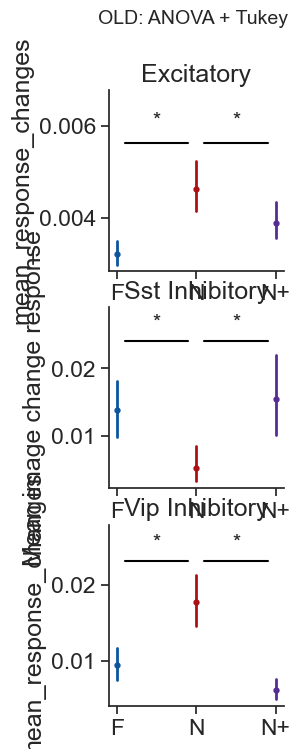


Old stats table:
     cell_type   group1  group2  reject  one_way_anova_p_val
    Excitatory Familiar   Novel    True         2.967995e-05
    Excitatory Familiar Novel +   False         2.967995e-05
    Excitatory    Novel Novel +    True         2.967995e-05
Sst Inhibitory Familiar   Novel    True         4.973032e-03
Sst Inhibitory Familiar Novel +   False         4.973032e-03
Sst Inhibitory    Novel Novel +    True         4.973032e-03
Vip Inhibitory Familiar   Novel    True         6.258495e-11
Vip Inhibitory Familiar Novel +   False         6.258495e-11
Vip Inhibitory    Novel Novel +    True         6.258495e-11


In [60]:
metric = 'mean_response_changes'
ylabel = 'Mean image change response'
event_type = 'changes'

# --- Plot with OLD stats ---
fig_old, ax_old = plt.subplots(3, 1, figsize=(2.25, 8), sharex=False, sharey=False)
old_tukey_table = pd.DataFrame()

for i, cell_type in enumerate(cell_types):
    ct_data = metrics_table[metrics_table.cell_type == cell_type].copy()
    colors = utils.get_experience_level_colors()
    
    ax_old[i] = sns.pointplot(data=ct_data, x='experience_level', y=metric, palette=colors, 
                               hue='experience_level', markers='.', markersize=5, 
                               err_kws={'linewidth': 2}, ax=ax_old[i])
    
    # OLD stats
    ax_old[i], tukey = ppf.add_stats_to_plot(ct_data, metric, ax_old[i])
    tukey['cell_type'] = cell_type
    tukey['metric'] = metric
    old_tukey_table = pd.concat([old_tukey_table, tukey])
    
    ax_old[i].set_xlabel('')
    ax_old[i].set_title(cell_type)
    ax_old[i].set_xticks(np.arange(0, len(utils.get_abbreviated_experience_levels())))
    ax_old[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)

ax_old[1].set_ylabel(ylabel)
fig_old.suptitle('OLD: ANOVA + Tukey', fontsize=14)
fig_old.subplots_adjust(wspace=0.4)
plt.show()

print("\nOld stats table:")
if 'reject' in old_tukey_table.columns:
    print(old_tukey_table[['cell_type', 'group1', 'group2', 'reject', 'one_way_anova_p_val']].to_string(index=False))
else:
    print(old_tukey_table.to_string(index=False))

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this messag

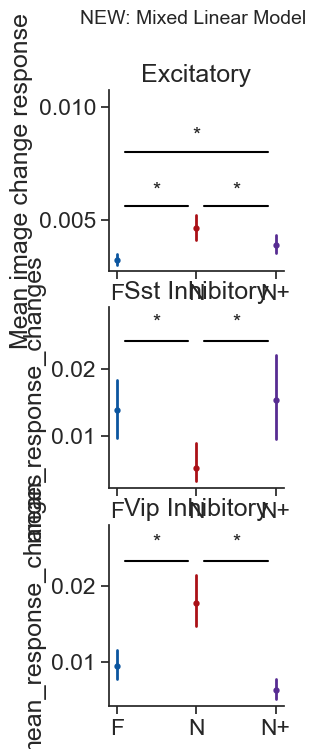


New stats table:
     cell_type   group1  group2      diff       pvalue  reject      icc model_type
    Excitatory Familiar   Novel  0.001414 4.630807e-06    True 0.017150        mlm
    Excitatory Familiar Novel +  0.000621 4.818131e-02    True 0.017150        mlm
    Excitatory    Novel Novel +  0.000793 9.973591e-03    True 0.017150        mlm
Sst Inhibitory Familiar   Novel -0.008758 7.679282e-03    True 0.042703        mlm
Sst Inhibitory Familiar Novel +  0.001152 7.297213e-01   False 0.042703        mlm
Sst Inhibitory    Novel Novel + -0.009910 2.643782e-03    True 0.042703        mlm
Vip Inhibitory Familiar   Novel  0.008473 3.753803e-07    True 0.045360        mlm
Vip Inhibitory Familiar Novel + -0.002811 8.632314e-02   False 0.045360        mlm
Vip Inhibitory    Novel Novel +  0.011284 1.986744e-11    True 0.045360        mlm


In [61]:
# --- Plot with NEW stats ---
fig_new, ax_new = plt.subplots(3, 1, figsize=(2.25, 8), sharex=False, sharey=False)
new_stats_table = pd.DataFrame()

for i, cell_type in enumerate(cell_types):
    ct_data = metrics_table[metrics_table.cell_type == cell_type].copy()
    colors = utils.get_experience_level_colors()
    
    ax_new[i] = sns.pointplot(data=ct_data, x='experience_level', y=metric, palette=colors, 
                               hue='experience_level', markers='.', markersize=5, 
                               err_kws={'linewidth': 2}, ax=ax_new[i])
    
    # NEW stats
    ax_new[i], pairwise = add_stats_to_plot_mlm(ct_data, metric, ax_new[i], group_column='mouse_id')
    pairwise['cell_type'] = cell_type
    new_stats_table = pd.concat([new_stats_table, pairwise])
    
    ax_new[i].set_xlabel('')
    ax_new[i].set_title(cell_type)
    ax_new[i].set_xticks(np.arange(0, len(utils.get_abbreviated_experience_levels())))
    ax_new[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)

ax_new[0].set_ylabel(ylabel)
fig_new.suptitle('NEW: Mixed Linear Model', fontsize=14)
fig_new.subplots_adjust(wspace=0.4)
plt.show()

print("\nNew stats table:")
print(new_stats_table[['cell_type', 'group1', 'group2', 'diff', 'pvalue', 'reject', 'icc', 'model_type']].to_string(index=False))

### Compare old vs new: which comparisons changed?

In [62]:
# Merge old and new results to see what changed
comparison_rows = []

for cell_type in cell_types:
    old_ct = old_tukey_table[old_tukey_table.cell_type == cell_type]
    new_ct = new_stats_table[new_stats_table.cell_type == cell_type]
    
    for _, new_row in new_ct.iterrows():
        # Find matching old row
        old_match = old_ct[(old_ct.group1 == new_row.group1) & (old_ct.group2 == new_row.group2)]
        
        if len(old_match) > 0:
            old_reject = old_match.iloc[0].get('reject', None)
        else:
            old_reject = None
        
        comparison_rows.append({
            'cell_type': cell_type,
            'comparison': f"{new_row.group1} vs {new_row.group2}",
            'old_reject': old_reject,
            'new_reject': new_row.reject,
            'new_pvalue': new_row.pvalue,
            'icc': new_row.icc,
            'changed': old_reject != new_row.reject if old_reject is not None else None
        })

comparison_df = pd.DataFrame(comparison_rows)
print("Comparison of old (ANOVA) vs new (MLM) results:")
print(comparison_df.to_string(index=False))
print()
n_changed = comparison_df['changed'].sum()
print(f"{n_changed} out of {len(comparison_df)} comparisons changed significance")

Comparison of old (ANOVA) vs new (MLM) results:
     cell_type          comparison  old_reject  new_reject   new_pvalue      icc  changed
    Excitatory   Familiar vs Novel        True        True 4.630807e-06 0.017150    False
    Excitatory Familiar vs Novel +       False        True 4.818131e-02 0.017150     True
    Excitatory    Novel vs Novel +        True        True 9.973591e-03 0.017150    False
Sst Inhibitory   Familiar vs Novel        True        True 7.679282e-03 0.042703    False
Sst Inhibitory Familiar vs Novel +       False       False 7.297213e-01 0.042703    False
Sst Inhibitory    Novel vs Novel +        True        True 2.643782e-03 0.042703    False
Vip Inhibitory   Familiar vs Novel        True        True 3.753803e-07 0.045360    False
Vip Inhibitory Familiar vs Novel +       False       False 8.632314e-02 0.045360    False
Vip Inhibitory    Novel vs Novel +        True        True 1.986744e-11 0.045360    False

1 out of 9 comparisons changed significance


### Save stats tables with different filenames to distinguish old vs new

When `add_stats_to_plot_mlm` is integrated into the plotting functions, 
stats tables should be saved with `_mlm.csv` suffix instead of `_tukey.csv`:

```python
# In plot_metric_distribution_by_experience, change:
#   tukey_table.to_csv(..., stats_filename + '_tukey.csv')
# to:
#   stats_table.to_csv(..., stats_filename + '_mlm.csv')
```

This enables direct comparison: for any figure, both `_tukey.csv` (old) and 
`_mlm.csv` (new) can coexist in the same directory.

In [63]:
# Demo: save both formats side by side
# old_tukey_table.to_csv(os.path.join(save_dir, folder, 'changes_filtered_events_mean_response_changes_tukey.csv'))
# new_stats_table.to_csv(os.path.join(save_dir, folder, 'changes_filtered_events_mean_response_changes_mlm.csv'))

# Preview what the saved new stats table looks like
print("Columns in new stats table:")
print(new_stats_table.columns.tolist())
print()
print("Full table that would be saved to _mlm.csv:")
print(new_stats_table.to_string(index=False))

Columns in new stats table:
['metric', 'event_type', 'column_to_compare', 'groups', 'group1', 'group2', 'x1', 'x2', 'diff', 'pvalue', 'reject', 'model_type', 'omnibus_pvalue', 'icc', 'mouse_variance', 'residual_variance', 'n_observations', 'n_groups', 'n_per_group', 'mean1_cells', 'mean2_cells', 'sem1_cells', 'sem2_cells', 'std1_cells', 'std2_cells', 'ci1_low_cells', 'ci2_low_cells', 'ci1_high_cells', 'ci2_high_cells', 'n1_cells', 'n2_cells', 'mean1_mouse', 'mean2_mouse', 'sem1_mouse', 'sem2_mouse', 'std1_mouse', 'std2_mouse', 'ci1_low_mouse', 'ci2_low_mouse', 'ci1_high_mouse', 'ci2_high_mouse', 'n1_mouse', 'n2_mouse', 'cell_type']

Full table that would be saved to _mlm.csv:
               metric event_type column_to_compare                     groups   group1  group2  x1  x2      diff       pvalue  reject model_type  omnibus_pvalue      icc  mouse_variance  residual_variance  n_observations  n_groups  n_per_group  mean1_cells  mean2_cells  sem1_cells  sem2_cells  std1_cells  std2_cel

### Test with additional metrics to verify robustness

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this messag

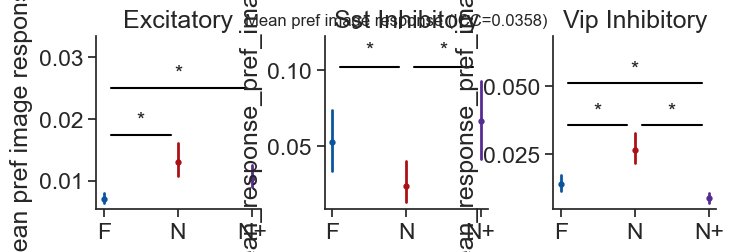

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this messag

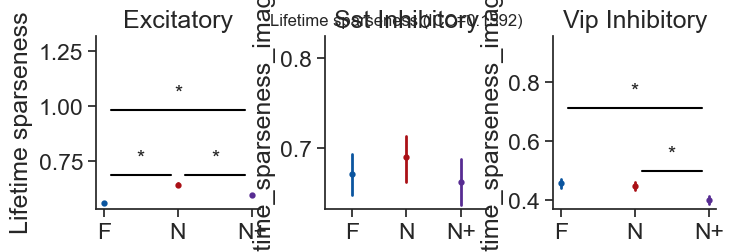

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this messag

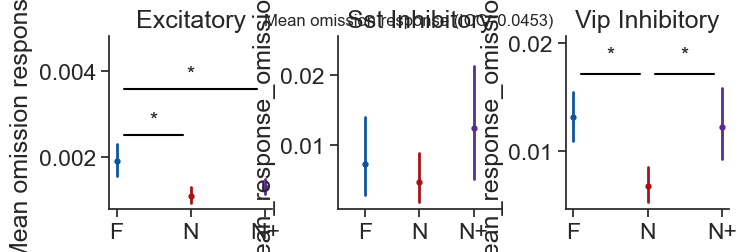

In [64]:
test_cases = [
    ('mean_response_pref_image', 'Mean pref image response'),
    ('lifetime_sparseness_images', 'Lifetime sparseness'),
    ('mean_response_omissions', 'Mean omission response'),
]

for metric_test, ylabel_test in test_cases:
    fig, ax = plt.subplots(1, 3, figsize=(8, 2.25), sharex=False, sharey=False)
    
    for i, cell_type in enumerate(cell_types):
        ct_data = metrics_table[metrics_table.cell_type == cell_type].copy()
        colors = utils.get_experience_level_colors()
        
        ax[i] = sns.pointplot(data=ct_data, x='experience_level', y=metric_test, palette=colors,
                               hue='experience_level', markers='.', markersize=5,
                               err_kws={'linewidth': 2}, ax=ax[i])
        ax[i], pairwise = add_stats_to_plot_mlm(ct_data, metric_test, ax[i], group_column='mouse_id')
        ax[i].set_xlabel('')
        ax[i].set_title(cell_type)
        ax[i].set_xticks(np.arange(0, len(utils.get_abbreviated_experience_levels())))
        ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)
    
    ax[0].set_ylabel(ylabel_test)
    icc_val = pairwise['icc'].iloc[0]
    fig.suptitle(f'{ylabel_test} (ICC={icc_val:.4f})', fontsize=12)
    fig.subplots_adjust(wspace=0.4)
    plt.show()

---
## Test with session-level behavior data (running speed)

This tests an important edge case: behavior metrics like running speed have one 
observation per session, not per cell. After dropping duplicate sessions, each 
mouse contributes ~1 observation per experience level. The function should detect 
this and fall back to standard ANOVA, since there's no meaningful nesting to 
account for.

This is the correct behavior — when data is already at the session/mouse level, 
a mixed model adds nothing and can actually cause problems (singular fits, etc.).

### Load running speed data

In [65]:
# params for stim response df creation
event_type = 'all'
data_type = 'running_speed'

interpolate = False
output_sampling_rate = None

# params for mean response df creation
conditions = ['ophys_experiment_id', 'is_change']

inclusion_criteria = 'platform_experiment_table' 

running_speed_suffix = '_'+utils.get_conditions_string(data_type, conditions)+'_'+inclusion_criteria

running_speed_mdf = loading.get_multi_session_df_for_conditions(data_type, event_type, conditions, inclusion_criteria,
                                                        interpolate=interpolate, output_sampling_rate=output_sampling_rate, 
                                                         epoch_duration_mins=None)

# save separately for images and changes and drop duplicates so each session is represented once
running_speed_mdf_changes = running_speed_mdf[running_speed_mdf.is_change==True]
running_speed_mdf_changes = running_speed_mdf_changes.drop_duplicates(subset='behavior_session_id')
running_speed_mdf_images = running_speed_mdf[running_speed_mdf.is_change==False]
running_speed_mdf_images = running_speed_mdf_images.drop_duplicates(subset='behavior_session_id')

print(f"{len(running_speed_mdf_changes)} sessions (changes)")
print(f"{running_speed_mdf_changes.mouse_id.nunique()} mice")
print(f"Mean sessions per mouse: {len(running_speed_mdf_changes) / running_speed_mdf_changes.mouse_id.nunique():.1f}")

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
there are 1880 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table
202 sessions (changes)
66 mice
Mean sessions per mouse: 3.1


### Check: does the function correctly fall back to ANOVA for session-level data?

In [66]:
metric = 'mean_response'

# Check the data structure
print("Observations per mouse per experience level:")
obs_per_group = running_speed_mdf_changes.groupby(['mouse_id', 'experience_level']).size()
print(f"  Mean: {obs_per_group.mean():.1f}")
print(f"  Min:  {obs_per_group.min()}")
print(f"  Max:  {obs_per_group.max()}")
print()

# Run the stats
results = test_significant_metric_averages_mlm(running_speed_mdf_changes, metric,
                                                column_to_compare='experience_level',
                                                group_column='mouse_id')

print(f"Model type: {results['model_type']}")
print(f"ICC: {results['icc']}")
print(f"Omnibus p-value: {results['omnibus_pvalue']:.4e}")
print()
print("Pairwise comparisons:")
print(results['pairwise'][['group1', 'group2', 'diff', 'pvalue', 'reject', 'model_type', 'n_observations', 'n_groups']].to_string(index=False))

Observations per mouse per experience level:
  Mean: 1.0
  Min:  1
  Max:  2

Model type: mlm
ICC: 0.7546852319329075
Omnibus p-value: 2.2487e-01

Pairwise comparisons:
  group1  group2      diff   pvalue  reject model_type  n_observations  n_groups
Familiar   Novel  1.145460 0.147545   False        mlm             202        66
Familiar Novel + -0.076434 0.922569   False        mlm             202        66
   Novel Novel +  1.221894 0.122370   False        mlm             202        66


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


### Plot with old vs new stats — running speed at changes

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_86305/390102647.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.wa

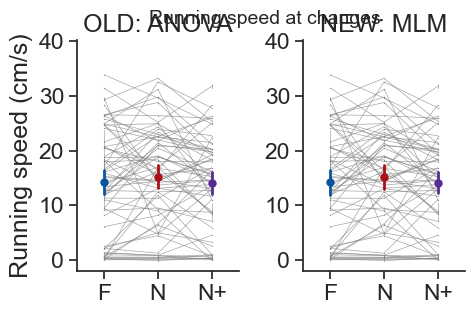


Old stats:
  group1  group2  reject
Familiar   Novel   False
Familiar Novel +   False
   Novel Novel +   False

New stats:
  group1  group2   pvalue  reject model_type      icc
Familiar   Novel 0.147545   False        mlm 0.754685
Familiar Novel + 0.922569   False        mlm 0.754685
   Novel Novel + 0.122370   False        mlm 0.754685


In [67]:
metric = 'mean_response'
ylabel = 'Running speed (cm/s)'
ylims = (-2, 35)
behavior_data = running_speed_mdf_changes.copy()
order = np.sort(behavior_data['experience_level'].unique())
colors = utils.get_experience_level_colors()

# --- OLD stats ---
fig, axes = plt.subplots(1, 2, figsize=(5, 3))

# Old
ax = axes[0]
for mouse_id in behavior_data.mouse_id.unique():
    ax = sns.pointplot(data=behavior_data[behavior_data.mouse_id == mouse_id], 
                       x='experience_level', y=metric, order=order,
                       color='gray', linewidth=0.5, markers='.', markersize=1, 
                       err_kws={'linewidth': 0.5}, ax=ax)
plt.setp(ax.collections, alpha=.7)
plt.setp(ax.lines, alpha=.7)
ax = sns.pointplot(data=behavior_data, x='experience_level', y=metric, 
                   hue='experience_level', order=order, hue_order=order,
                   palette=colors, dodge=0, linestyle='None',
                   markers='.', markersize=8, err_kws={'linewidth': 2}, ax=ax)
_legend = ax.get_legend()
if _legend: _legend.remove()
ax.set_ylim(ylims)
ax.set_xlim(-0.5, len(order) - 0.5)
ax, old_tukey = ppf.add_stats_to_plot(behavior_data, metric, ax, ymax=ylims[1], show_ns=False)
ax.set_xlabel('')
ax.set_ylabel(ylabel)
ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)
ax.set_title('OLD: ANOVA')

# New 
ax = axes[1]
for mouse_id in behavior_data.mouse_id.unique():
    ax = sns.pointplot(data=behavior_data[behavior_data.mouse_id == mouse_id], 
                       x='experience_level', y=metric, order=order,
                       color='gray', linewidth=0.5, markers='.', markersize=1, 
                       err_kws={'linewidth': 0.5}, ax=ax)
plt.setp(ax.collections, alpha=.7)
plt.setp(ax.lines, alpha=.7)
ax = sns.pointplot(data=behavior_data, x='experience_level', y=metric, 
                   hue='experience_level', order=order, hue_order=order,
                   palette=colors, dodge=0, linestyle='None',
                   markers='.', markersize=8, err_kws={'linewidth': 2}, ax=ax)
_legend = ax.get_legend()
if _legend: _legend.remove()
ax.set_ylim(ylims)
ax.set_xlim(-0.5, len(order) - 0.5)
ax, new_pairwise = add_stats_to_plot_mlm(behavior_data, metric, ax, ymax=ylims[1], 
                                          group_column='mouse_id')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)
ax.set_title(f"NEW: {new_pairwise['model_type'].iloc[0].upper()}")

fig.suptitle('Running speed at changes', fontsize=14)
fig.subplots_adjust(wspace=0.4)
plt.show()

print("\nOld stats:")
if 'reject' in old_tukey.columns:
    print(old_tukey[['group1', 'group2', 'reject']].to_string(index=False))
print("\nNew stats:")
print(new_pairwise[['group1', 'group2', 'pvalue', 'reject', 'model_type', 'icc']].to_string(index=False))

### Also test running speed at images

In [68]:
behavior_data_images = running_speed_mdf_images.copy()

results_images = test_significant_metric_averages_mlm(behavior_data_images, metric,
                                                       column_to_compare='experience_level',
                                                       group_column='mouse_id')

print(f"Running speed at images:")
print(f"  Model type: {results_images['model_type']}")
print(f"  ICC: {results_images['icc']}")
print(f"  N observations: {len(behavior_data_images)}, N mice: {behavior_data_images.mouse_id.nunique()}")
print(f"  Mean obs per mouse per condition: {behavior_data_images.groupby(['mouse_id', 'experience_level']).size().mean():.1f}")
print()
print(results_images['pairwise'][['group1', 'group2', 'pvalue', 'reject', 'model_type']].to_string(index=False))

Running speed at images:
  Model type: mlm
  ICC: 0.8274682343491971
  N observations: 202, N mice: 66
  Mean obs per mouse per condition: 1.0

  group1  group2   pvalue  reject model_type
Familiar   Novel 0.548986   False        mlm
Familiar Novel + 0.645138   False        mlm
   Novel Novel + 0.887575   False        mlm


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


### Summary of behavior data tests

The behavior metrics have ~1 observation per mouse per experience level (after 
dropping duplicate sessions), so the function correctly falls back to standard 
ANOVA. The stats results and star placement should match the old approach, since 
both are using ANOVA when the data isn't nested.

If some mice have multiple sessions per experience level (mean obs > 1), the 
function will use MLM instead — which is also correct, since in that case there 
IS nesting to account for.

---
## Plotting helper: cell-level distribution + mouse-level error bars

When reporting MLM-based p-values, error bars on the figure should match the unit
of analysis the model uses (mouse, not cell). The helper below draws a cell-level
distribution (violin/box/strip/swarm) and overlays a `pointplot` of per-mouse
means with across-mouse 95% CIs (or SEM/SD), so the visual story matches the stats.

This is meant to live in `visual_behavior_analysis` proper eventually -- for now
it sits at the end of this notebook for iteration.


In [69]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_cells_with_mouse_summary(
    data,
    metric,
    x,
    group_column='mouse_id',
    hue=None,
    order=None,
    hue_order=None,
    base_kind='violin',
    base_kwargs=None,
    summary_errorbar=('ci', 95),
    summary_color='black',
    summary_kwargs=None,
    ax=None,
):
    """
    Plot cell-level distributions with an overlay of per-mouse means and
    across-mouse error bars.

    The base layer shows the spread of cell-level observations (violin / box /
    strip / swarm). The overlay is a seaborn ``pointplot`` of per-(mouse, condition)
    means -- so the plotted error bars are computed across mice, matching the
    unit of analysis used by the MLM. This is the appropriate error bar to show
    alongside MLM-derived p-values.

    Parameters
    ----------
    data : pd.DataFrame
        Cell-level (or generally, observation-level) data.
    metric : str
        Column to plot on the y-axis.
    x : str
        Categorical x-axis column (e.g. ``experience_level``).
    group_column : str, default ``'mouse_id'``
        Column identifying the experimental unit to aggregate by before computing
        the summary error bars.
    hue : str, optional
        Optional hue column. If provided, both base and summary layers split by hue.
    order, hue_order : list, optional
        Category orders, forwarded to both layers.
    base_kind : {'violin', 'box', 'strip', 'swarm', None}, default 'violin'
        Type of cell-level layer. Use ``None`` to skip and only draw the summary.
    base_kwargs : dict, optional
        Extra kwargs for the base seaborn function. ``inner=None`` is set by
        default for ``violin`` so its built-in summary doesn't compete with the
        overlay.
    summary_errorbar : seaborn errorbar spec, default ``('ci', 95)``
        Error bar type for the mouse-level overlay. Examples:
        ``('ci', 95)`` for 95% CI, ``'se'`` for SEM, ``'sd'`` for SD,
        ``None`` to suppress error bars.
    summary_color : str, default ``'black'``
        Color for the overlay markers and bars (ignored if ``hue`` is set, since
        seaborn will color by hue automatically).
    summary_kwargs : dict, optional
        Extra kwargs for the overlay ``pointplot`` (e.g. ``markersize``, ``capsize``).
    ax : matplotlib.axes.Axes, optional
        Axes to draw on. If ``None``, the current axes are used.

    Returns
    -------
    ax : matplotlib.axes.Axes
    mouse_means : pd.DataFrame
        The per-(mouse, condition[, hue]) aggregated frame used for the overlay.

    Notes
    -----
    Seaborn >= 0.12 is required for the ``errorbar=`` argument. Older versions
    use ``ci=95`` instead.

    Examples
    --------
    >>> ax, mouse_means = plot_cells_with_mouse_summary(
    ...     data=cells_df, metric='mean_response_pref_image',
    ...     x='experience_level', group_column='mouse_id',
    ...     base_kind='violin',
    ... )
    """
    if ax is None:
        ax = plt.gca()

    base_kwargs = dict(base_kwargs or {})
    summary_kwargs = dict(summary_kwargs or {})

    # --- Base layer: cell-level distribution ---
    base_call_kwargs = dict(data=data, x=x, y=metric, ax=ax)
    if hue is not None:
        base_call_kwargs['hue'] = hue
    if order is not None:
        base_call_kwargs['order'] = order
    if hue_order is not None:
        base_call_kwargs['hue_order'] = hue_order

    if base_kind == 'violin':
        # inner=None so seaborn's built-in summary doesn't compete with the overlay
        base_call_kwargs.setdefault('inner', None)
        base_call_kwargs.update(base_kwargs)
        sns.violinplot(**base_call_kwargs)
    elif base_kind == 'box':
        # Suppress fliers/whiskers caps for a cleaner backdrop; users can override.
        base_call_kwargs.update(base_kwargs)
        sns.boxplot(**base_call_kwargs)
    elif base_kind == 'strip':
        base_call_kwargs.update(base_kwargs)
        sns.stripplot(**base_call_kwargs)
    elif base_kind == 'swarm':
        base_call_kwargs.update(base_kwargs)
        sns.swarmplot(**base_call_kwargs)
    elif base_kind is None:
        pass
    else:
        raise ValueError(
            f"base_kind must be one of 'violin', 'box', 'strip', 'swarm', or None; "
            f"got {base_kind!r}"
        )

    # --- Aggregate to (mouse, condition[, hue]) means ---
    group_keys = [group_column, x]
    if hue is not None and hue != x:
        group_keys.append(hue)
    mouse_means = (
        data.dropna(subset=[metric])
            .groupby(group_keys, dropna=False)[metric]
            .mean()
            .reset_index()
    )

    # --- Overlay: pointplot of per-mouse means with across-mouse error bars ---
    overlay_kwargs = dict(
        data=mouse_means, x=x, y=metric, ax=ax,
        errorbar=summary_errorbar,
        linestyle='none',  # don't connect category centers (seaborn >= 0.13)
        markers='o',
        capsize=0.15,
        err_kws={'linewidth': 1.5},
    )
    if hue is not None:
        overlay_kwargs['hue'] = hue
        overlay_kwargs['dodge'] = base_call_kwargs.get('dodge', 0.3)
    else:
        overlay_kwargs['color'] = summary_color
    if order is not None:
        overlay_kwargs['order'] = order
    if hue_order is not None:
        overlay_kwargs['hue_order'] = hue_order
    overlay_kwargs.update(summary_kwargs)

    try:
        sns.pointplot(**overlay_kwargs)
    except TypeError:
        # Fallback for seaborn < 0.13: no `linestyle` kwarg, use `join=False` and
        # the legacy `ci=` arg.
        legacy_kwargs = {k: v for k, v in overlay_kwargs.items()
                         if k not in ('linestyle', 'errorbar', 'err_kws')}
        legacy_kwargs['join'] = False
        if isinstance(summary_errorbar, tuple) and summary_errorbar[0] == 'ci':
            legacy_kwargs['ci'] = summary_errorbar[1]
        elif summary_errorbar is None:
            legacy_kwargs['ci'] = None
        else:
            legacy_kwargs['ci'] = 95
        sns.pointplot(**legacy_kwargs)

    return ax, mouse_means
